<a href="https://colab.research.google.com/github/srivastavabarkha000-oss/assignment-01--2511918-/blob/main/part4-vector-db/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ERROR: Invalid requirement: 'sentence-transformers,': Expected end or semicolon (after name and no valid version specifier)
    sentence-transformers,
                         ^


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10, 384)


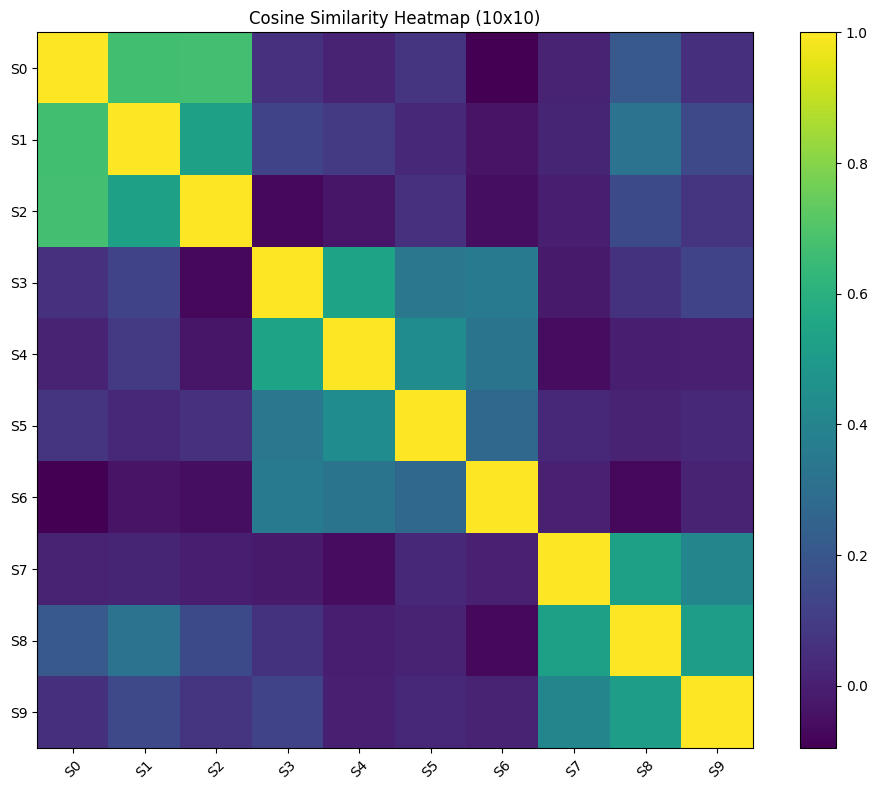


Query: The bowler took three wickets in one over

Top 2 most similar sentences:
- India dominates the sport of Cricket (Score: 0.4707)
- Cricket is played on a pitch of 22 yards (Score: 0.4506)


In [2]:
!pip3 install -q sentence-transformers, scikit-learn, matplotlib;

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# Load a pre-trained embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Define sample sentences
sentences = [
    "Cricket is played across 20 countries in the world",
    "India dominates the sport of Cricket",
    "Cricket is played on a pitch of 22 yards",
    "Cooking is one of the hardest jobs in the world",
    "Women love cooking for their families",
    "Proper kitchen setup should be provided for cooking in restaurants",
    "Early man started cooking with the discovery of fire",
    "Cybersecurity is becoming increasingly important for personal identifiable information",
    "Cybersecurity crimes are increasing in India",
    "Poor cybersecurity strategy makes a company vulnerable to cyber attacks"
]

# Generate vector embeddings
vectors = model.encode(sentences)

print(f"Embedding shape: {vectors.shape}")

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(vectors)

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix)
plt.colorbar()

# Add labels
plt.xticks(ticks=range(len(sentences)), labels=[f"S{i}" for i in range(len(sentences))], rotation=45)
plt.yticks(ticks=range(len(sentences)), labels=[f"S{i}" for i in range(len(sentences))])

plt.title("Cosine Similarity Heatmap (10x10)")
plt.tight_layout()
plt.show()


# New query sentence
query = "The bowler took three wickets in one over"

# Encode the query
query_vector = model.encode([query])

# Compute similarity with existing sentence vectors
query_similarities = cosine_similarity(query_vector, vectors)[0]

# Get top 2 most similar sentences
top_indices = np.argsort(query_similarities)[-2:][::-1]

print(f"\nQuery: {query}\n")

print("Top 2 most similar sentences:")
for idx in top_indices:
    print(f"- {sentences[idx]} (Score: {query_similarities[idx]:.4f})")
